## Overview

This notebook conducts an in depth study into the use of physics informed neural networks (PINNs) for the 1D heat equation, and tries to quantify how relevant they actually are compared to a classical baseline solver. The main question is whether a PINN is actually worth the extra training and tuning cost when a classical method already solves this problem well.

We look at two versions of the problem.

Forward problem: we know the diffusivity and just need to solve for the temperature. We compare a baseline PINN, using standard hyperparameters from the literature, against a PINN tuned with Optuna (a 300 trial search), and both against the finite difference solver. We also test how the results change across different diffusivity values, and check how the finite difference solver's accuracy improves as the grid gets finer.

Inverse problem: we only have a few noisy temperature measurements and need to recover the diffusivity from them. We compare a baseline PINN, a tuned PINN, and a classical least squares method that uses the finite difference solver (CN-NLS). It would be easy to accidentally evaluate a config on the same data used to pick it, so this is split into three stages: search, confirmation, and final evaluation. That way the number we report is never influenced by the data used to select the winning config. We also test how results change with different noise levels, number of observations, and diffusivity values.

For every comparison we report both accuracy and cost: training time, how long it takes to evaluate the trained model, and how long the Optuna search itself took. We also added a CPU only timing run for the PINNs so training time can be compared on the same hardware as the finite difference solver, since PINN training normally runs on GPU and the finite difference solver runs on CPU.

All of the actual model and training code lives in pinn_core.py. This notebook is what runs it. heat_pinn_basic.ipynb was an earlier version of this same code and has been removed since everything it did is now handled here.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import time
import joblib
import optuna
import optuna.visualization as vis

from pinn_core import (
    set_seed, pinn_architecture, sample_points, generate_noisy_data,
    compute_loss, train_forward, compute_loss_inverse, train_inverse,
    fd_solver, cn_nls_baseline,
)

torch.manual_seed(123)
np.random.seed(123)

#for traing_forward and train_inverse: defaults to GPU if available, else CPU.
default_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Auto-detected default device: {default_device}")

Using device: cuda


Literature informed initial forward config

In [ ]:
forward_config = {
    # N_bc is actually points per boundary (x=0 and x=1), so the total number of boundary points is 2*N_bc.
    "N_f": 10000,
    "N_bc": 200,
    "N_ic": 200,
    "adam_lr": 1e-3,
    "adam_iters": 2000,
    "lbfgs_iters": 500,
    "hidden_size": 20,
    "n_layers": 4,
    "true_alpha": 0.4,
}

**TODO:** Explain why this held-out test grid is built once here and reused by every section below instead of each section building its own (train/test leakage prevention).

In [ ]:
#Test grid for plotting and error computation
x_test = torch.linspace(0, 1, 1000)
t_test = torch.linspace(0, 1, 1000)
X_test, T_test = torch.meshgrid(x_test, t_test, indexing='ij')
x_test_flat = X_test.reshape(-1, 1)
t_test_flat = T_test.reshape(-1, 1)

# Exact solution on the test grid
u_exact_test = torch.sin(torch.pi * x_test_flat) * torch.exp(-forward_config["true_alpha"] * (torch.pi**2) * t_test_flat)

here we train the pinn based off of the literature informed baseline config across 5 different seeds recording training time, rel L2 error, and inference time. 

In [ ]:
#baseline forward PINN from literature informed hyperparameters.
#trained across 5 random seeds to prevent bias from a single lucky seed.
baseline_forward_results = []
for seed in range(5):
    set_seed(seed)
    start = time.time()
    results = train_forward(forward_config, print_training=False)
    results['elapsed'] = time.time() - start
    baseline_forward_results.append(results)

baseline_val_errors = [r['rel_l2'] for r in baseline_forward_results]
baseline_val_times = [r['elapsed'] for r in baseline_forward_results]
print(f"\nBaseline (no tuning):")
print(f"  Error (validation grid): {np.mean(baseline_val_errors):.6e} ± {np.std(baseline_val_errors):.6e}")
print(f"  Time:  {np.mean(baseline_val_times):.2f} ± {np.std(baseline_val_times):.2f} sec")

#Tests the baseline trained on the 5 random seeds on the held-out test grid, and reports the mean and std of the relative L2 error and inference time.
baseline_test_errors = []
baseline_test_linf_errors = []
baseline_infer_times = []
for r in baseline_forward_results:
    model_device = next(r["model"].parameters()).device
    infer_start = time.time()
    with torch.no_grad():
        u_pred_test = r["model"](x_test_flat.to(model_device), t_test_flat.to(model_device)).cpu()
    baseline_infer_times.append(time.time() - infer_start)
    baseline_test_errors.append((torch.norm(u_pred_test - u_exact_test) / torch.norm(u_exact_test)).item())
    baseline_test_linf_errors.append(torch.max(torch.abs(u_pred_test - u_exact_test)).item())

baseline_test_rel_l2_mean = float(np.mean(baseline_test_errors))
baseline_test_rel_l2_std = float(np.std(baseline_test_errors))
baseline_test_linf_mean = float(np.mean(baseline_test_linf_errors))
baseline_test_linf_std = float(np.std(baseline_test_linf_errors))
baseline_train_time_mean = float(np.mean(baseline_val_times))
baseline_train_time_std = float(np.std(baseline_val_times))
baseline_infer_time_mean = float(np.mean(baseline_infer_times))
baseline_infer_time_std = float(np.std(baseline_infer_times))

print(f"  Held-out test rel L2 error: {baseline_test_rel_l2_mean:.6e} ± {baseline_test_rel_l2_std:.6e}")
print(f"  Held-out test L-inf error:  {baseline_test_linf_mean:.6e} ± {baseline_test_linf_std:.6e}")
print(f"  Training time:              {baseline_train_time_mean:.2f} ± {baseline_train_time_std:.2f} sec")
print(f"  Field-evaluation time:      {baseline_infer_time_mean:.4f} ± {baseline_infer_time_std:.4f} sec")

c:\Users\James\Documents\GitHub\HEAT_PINN\.venv\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass



PINN total training time: 11.89s
Rel L2 error: 2.2134e-03

PINN total training time: 14.08s
Rel L2 error: 1.4384e-03

PINN total training time: 14.21s
Rel L2 error: 4.5672e-03

PINN total training time: 12.06s
Rel L2 error: 4.3954e-03

PINN total training time: 9.33s
Rel L2 error: 6.5111e-03

Baseline (no tuning):
  Error (validation grid): 3.825091e-03 ± 1.810205e-03
  Time:  12.54 ± 1.78 sec
  Held-out test rel L2 error: 3.827103e-03 ± 1.810356e-03
  Training time:              12.54 ± 1.78 sec
  Field-evaluation time:      0.0012 ± 0.0015 sec


Setup of optuna sweep and search parameters. here we set lambda_pde = 1 and let the other lambda values adjust based off of that normalization. 

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

#Note: lambda_pde is held at one to because all that matters is the relative weighting of the three loss terms, and the other two lambdas are tuned.
FORWARD_FIXED_CONFIG = {
    "lambda_pde": 1.0,
    "true_alpha": 0.4,
}

#search space for Optuna tuning of forward PINN hyperparameters.
#suggest_categorical tests descrete values as shown, suggest_float tests continuous values in the range shown (log=True means the range is sampled logarithmically).
def objective_forward(trial):
    config = {
        **FORWARD_FIXED_CONFIG,
        "hidden_size":  trial.suggest_categorical("hidden_size", [16, 32, 64, 128]),
        "n_layers":     trial.suggest_categorical("n_layers", [3, 4, 5]),
        "activation":   trial.suggest_categorical("activation", ["tanh", "sin"]),
        "lambda_bc":    trial.suggest_float("lambda_bc",  0.001, 1000.0, log=True),
        "lambda_ic":    trial.suggest_float("lambda_ic",  0.001, 1000.0, log=True),
        "N_f":          trial.suggest_categorical("N_f", [5000, 10000, 20000]),
        "N_bc":         trial.suggest_categorical("N_bc", [100, 200, 400]),
        "N_ic":         trial.suggest_categorical("N_ic", [100, 200, 400]),
        "adam_lr":      trial.suggest_float("adam_lr", 1e-4, 1e-2, log=True),
        #Smaller amount of optimizer calls to speed up Optuna search, since the goal is to find a good region of hyperparameter space, not to fully converge each trial.
        "adam_iters":   1500,
        "lbfgs_iters":  500,
    }

    results = train_forward(config, print_training = False, trial = trial)
    return results["rel_l2"]

: 

run of optuna search sweep. Running 300 trials with a pruner that prunes based off of the median at intervals of 200 steps after an 8

In [ ]:
if os.path.exists("optuna_forward.db"):
    os.remove("optuna_forward.db")

study = optuna.create_study(
    direction="minimize",
    study_name="forward_pinn_hpo",
    storage="sqlite:///optuna_forward.db",
    load_if_exists=True,
    # Median pruner: cut a trial early if it's doing worse than the median of
    # past trials at the same point. Waits for 15 trials before comparing (need
    # a real median to compare against) and 800 steps into each trial before
    # judging it (early training is noisy), then only rechecks every 200 steps.
    pruner=optuna.pruners.MedianPruner(n_startup_trials=15, n_warmup_steps=800, interval_steps=200),
    sampler=optuna.samplers.TPESampler(seed=42)
)

optuna_forward_search_start = time.time()
study.optimize(
    objective_forward,
    n_trials=300,
    show_progress_bar=True
)
optuna_forward_search_time = time.time() - optuna_forward_search_start

joblib.dump(study, 'forward_hpo_study.pkl')

print(f"\nTotal Optuna forward search time: {optuna_forward_search_time:.2f}s")

# Top 5 trials under specific seed (42)
print(f"\nTop 5 trials:")
sorted_trials = sorted(study.trials, key=lambda t: t.value if t.value is not None else float('inf'))
for i, trial in enumerate(sorted_trials[:5], 1):
    print(f"{i}. Error: {trial.value:.6e}")
    print(f"   Params: {trial.params}\n")

# Stats
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE] 
pruned = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
print(f"Summary:")
print(f"  Completed: {len(completed)}")
print(f"  Pruned: {len(pruned)}")
print(f"  Pruning saved: {len(pruned)/(len(completed)+len(pruned))*100:.1f}% of trials")

opt_history_fig = vis.plot_optimization_history(study)
opt_history_fig.update_yaxes(type="log")
opt_history_fig.show()
vis.plot_param_importances(study).show()

**TODO:** Explain why the winning config is chosen by mean validation error across 5 seeds rather than any single run's error, and what the representative-run plot two cells below is (and is not) showing.

In [ ]:
#Retrain top 3 configs on a full run of training (3000/1500 adam/lbfgs iterations).
top_configs = [
    {**FORWARD_FIXED_CONFIG, **trial.params, "adam_iters": 3000, "lbfgs_iters": 1500}
    for trial in sorted_trials[:3]
]

all_config_results = []

#Train each of the top 3 configs across 5 random seeds, and report the mean and std of the validation error and training time.
for i, config in enumerate(top_configs, 1):
    config_results = []
    for seed in range(5):
        set_seed(seed)
        start = time.time()
        results = train_forward(config, print_training=False)
        results['elapsed'] = time.time() - start
        config_results.append(results)

    errors = [r['rel_l2'] for r in config_results]
    times = [r['elapsed'] for r in config_results]
    print(f"\nConfig {i}:")
    print(f"  Error (validation grid): {np.mean(errors):.6e} ± {np.std(errors):.6e}")
    print(f"  Time:  {np.mean(times):.2f} ± {np.std(times):.2f} sec")

    all_config_results.append(config_results)

# Pick the winning config by its MEAN validation error across 5 seeds to avoid bias toward a single lucky run.
config_mean_errors = [np.mean([r['rel_l2'] for r in cr]) for cr in all_config_results]
best_config_idx = int(np.argmin(config_mean_errors))
winning_results = all_config_results[best_config_idx]

#Each winning config is evaluated on the held-out test grid for each seed to compute the mean and std of the relative L2 error and inference time. 
#This test grid is never used during HPO or config selection, so this mean/std, not any single run's number, is what should be quoted as "PINN accuracy." 
test_errors = []
test_linf_errors = []
test_infer_times = []
for r in winning_results:
    model_device = next(r["model"].parameters()).device
    infer_start = time.time()
    with torch.no_grad():
        u_pred_test = r["model"](x_test_flat.to(model_device), t_test_flat.to(model_device)).cpu()
    test_infer_times.append(time.time() - infer_start)
    test_errors.append((torch.norm(u_pred_test - u_exact_test) / torch.norm(u_exact_test)).item())
    test_linf_errors.append(torch.max(torch.abs(u_pred_test - u_exact_test)).item())

pinn_test_rel_l2_mean = float(np.mean(test_errors))
pinn_test_rel_l2_std = float(np.std(test_errors))
pinn_test_linf_mean = float(np.mean(test_linf_errors))
pinn_test_linf_std = float(np.std(test_linf_errors))
pinn_infer_time_mean = float(np.mean(test_infer_times))
pinn_infer_time_std = float(np.std(test_infer_times))
pinn_train_time_mean = float(np.mean([r["elapsed"] for r in winning_results]))
pinn_train_time_std = float(np.std([r["elapsed"] for r in winning_results]))

print(f"\nWinning config: Config {best_config_idx + 1}")
print(f"  Held-out test rel L2 error: {pinn_test_rel_l2_mean:.6e} ± {pinn_test_rel_l2_std:.6e}")
print(f"  Held-out test L-inf error:  {pinn_test_linf_mean:.6e} ± {pinn_test_linf_std:.6e}")
print(f"  Training time:              {pinn_train_time_mean:.2f} ± {pinn_train_time_std:.2f} sec")
print(f"  Field-evaluation time:      {pinn_infer_time_mean:.4f} ± {pinn_infer_time_std:.4f} sec")

#plots are based on whichever seed's model is closest to the mean validation error.
representative_idx = int(np.argmin([abs(r['rel_l2'] - config_mean_errors[best_config_idx]) for r in winning_results]))
best_result = winning_results[representative_idx]

model = best_result["model"]
pinn_train_time = best_result["train_time"]


PINN total training time: 19.63s
Rel L2 error: 2.5270e-04

PINN total training time: 19.64s
Rel L2 error: 2.5231e-04

PINN total training time: 20.65s
Rel L2 error: 2.9788e-04

PINN total training time: 21.08s
Rel L2 error: 1.9546e-04

PINN total training time: 19.72s
Rel L2 error: 3.5856e-04

Config 1:
  Error (validation grid): 2.713830e-04 ± 5.436688e-05
  Time:  20.17 ± 0.60 sec

PINN total training time: 20.46s
Rel L2 error: 2.6203e-04

PINN total training time: 15.54s
Rel L2 error: 7.2141e-04

PINN total training time: 19.84s
Rel L2 error: 2.1161e-04

PINN total training time: 21.52s
Rel L2 error: 2.7263e-04

PINN total training time: 21.62s
Rel L2 error: 2.0462e-04

Config 2:
  Error (validation grid): 3.344597e-04 ± 1.953200e-04
  Time:  19.82 ± 2.23 sec

PINN total training time: 18.91s
Rel L2 error: 2.2160e-04

PINN total training time: 14.35s
Rel L2 error: 1.7774e-03

PINN total training time: 22.28s
Rel L2 error: 6.4893e-04

PINN total training time: 20.38s
Rel L2 error: 2

PINN inference time : 0.0119s
PINN rel L2 error   : 2.5301e-04
PINN L-inf error    : 3.7371e-04


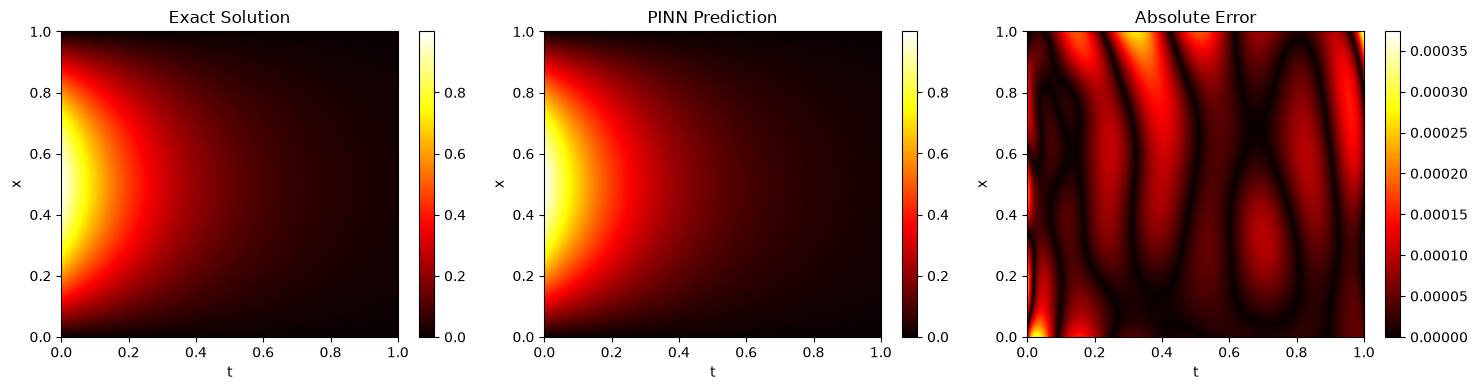

In [11]:
# Reuse the held-out test grid built above (x_test/t_test/X_test/T_test/...)
# instead of rebuilding an identical one from scratch -- same points, so
# there's no reason to maintain two copies of the same grid construction.
x, t = x_test, t_test
X, T = X_test, T_test
x_flat, t_flat = x_test_flat, t_test_flat

# Move inputs to whichever device the winning model actually trained on
# (GPU by default, or CPU for an explicit CPU control-timing run), and
# bring the prediction back to CPU right after -- everything downstream
# (numpy conversion, plotting, error math) is unchanged.
model_device = next(model.parameters()).device
pinn_infer_start = time.time()
with torch.no_grad():
    u_pred = model(x_flat.to(model_device), t_flat.to(model_device)).cpu()
pinn_infer_time = time.time() - pinn_infer_start

u_exact = u_exact_test

error = torch.norm(u_pred - u_exact) / torch.norm(u_exact)
linf_error_pinn = torch.max(torch.abs(u_pred - u_exact)).item()

print(f"PINN inference time : {pinn_infer_time:.4f}s")
print(f"PINN rel L2 error   : {error.item():.4e}")
print(f"PINN L-inf error    : {linf_error_pinn:.4e}")

u_pred_grid = u_pred.reshape(1000, 1000)
u_exact_grid = u_exact.reshape(1000, 1000)
u_abs_error = torch.abs(u_pred - u_exact).reshape(1000, 1000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 - exact solution
im1 = axes[0].pcolormesh(T.numpy(), X.numpy(), u_exact_grid.numpy(), cmap='hot')
axes[0].set_title('Exact Solution')
axes[0].set_xlabel('t')
axes[0].set_ylabel('x')
plt.colorbar(im1, ax=axes[0])

# Plot 2 - PINN prediction
im2 = axes[1].pcolormesh(T.numpy(), X.numpy(), u_pred_grid.numpy(), cmap='hot')
axes[1].set_title('PINN Prediction')
axes[1].set_xlabel('t')
axes[1].set_ylabel('x')
plt.colorbar(im2, ax=axes[1])

# Plot 3 - absolute error
im3 = axes[2].pcolormesh(T.numpy(), X.numpy(), u_abs_error.numpy(), cmap='hot')
axes[2].set_title('Absolute Error')
axes[2].set_xlabel('t')
axes[2].set_ylabel('x')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

**TODO:** Explain what this convergence study demonstrates about the Crank-Nicolson solver's accuracy as grid resolution increases.

In [12]:
conv_errors = []
N_values = [10, 50, 100, 500, 1000, 5000]

for nx in N_values:
    x_c, t_c, u_c, conv_error = fd_solver(nx, nx)
    conv_errors.append(conv_error)

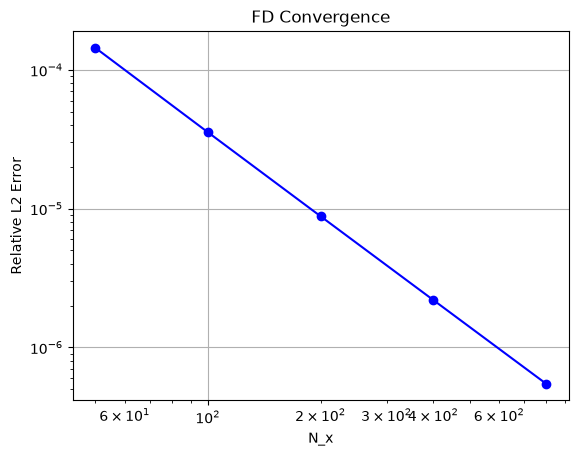

In [13]:
plt.figure()
plt.loglog(N_values, conv_errors, 'bo-', label='CN Error')
plt.xlabel('N_x')
plt.ylabel('Relative L2 Error')
plt.title('FD Convergence')
plt.grid(True)
plt.show()

**TODO:** Explain what the five-panel plot and the Baseline/Tuned/FD table below are comparing, and why FD's cost is measured on CPU while the PINN's is measured on GPU.

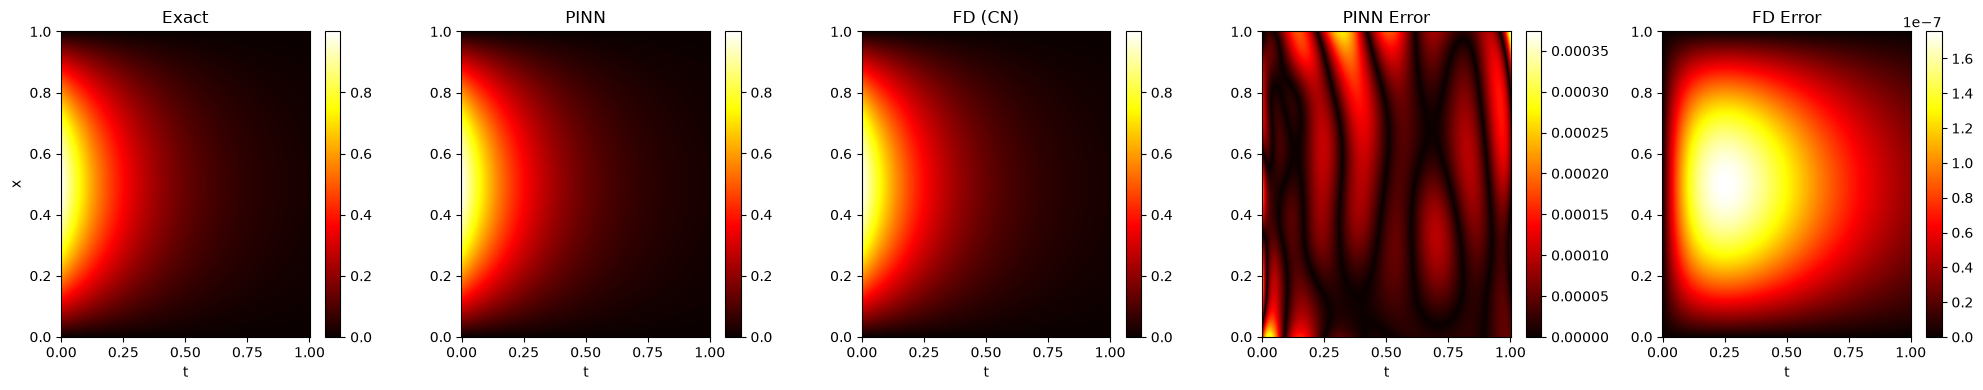

                                Baseline          Tuned        FD (CN)
----------------------------------------------------------------------
Training time (s)                    N/A          19.63            N/A
  mean ± std (5 seeds)        12.54±1.78     20.17±0.60            N/A
Inference time (s)                   N/A         0.0119         0.0211
  mean ± std (5 seeds)     0.0012±0.0015            N/A            N/A
Rel L2 error                         N/A     2.5301e-04     3.3437e-07
  mean ± std (5 seeds)    3.8271e-03±1.8104e-03 2.7186e-04±5.4299e-05            N/A
L-inf error                          N/A     3.7371e-04     1.7558e-07
Optuna search time (s)               N/A        2874.68            N/A


In [14]:
fd_start = time.time()
x_fd, t_fd, u_fd, _ = fd_solver(1000, 1000, compute_error=False)
fd_time = time.time() - fd_start

X_fd, T_fd = np.meshgrid(x_fd, t_fd, indexing='ij')
u_exact_fd = np.sin(np.pi * X_fd) * np.exp(-forward_config["true_alpha"] * (np.pi**2) * T_fd)
error_fd = np.linalg.norm(u_fd - u_exact_fd) / np.linalg.norm(u_exact_fd)
linf_error_fd = np.max(np.abs(u_fd - u_exact_fd))

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Exact
im1 = axes[0].pcolormesh(T.numpy(), X.numpy(), u_exact_grid.numpy(), cmap='hot')
axes[0].set_title('Exact')
axes[0].set_xlabel('t')
axes[0].set_ylabel('x')
plt.colorbar(im1, ax=axes[0])

# PINN prediction
im2 = axes[1].pcolormesh(T.numpy(), X.numpy(), u_pred_grid.numpy(), cmap='hot')
axes[1].set_title('PINN')
axes[1].set_xlabel('t')
plt.colorbar(im2, ax=axes[1])

# FD prediction
im3 = axes[2].pcolormesh(T.numpy(), X.numpy(), u_fd, cmap='hot')
axes[2].set_title('FD (CN)')
axes[2].set_xlabel('t')
plt.colorbar(im3, ax=axes[2])

# PINN error
im4 = axes[3].pcolormesh(T.numpy(), X.numpy(), u_abs_error.numpy(), cmap='hot')
axes[3].set_title('PINN Error')
axes[3].set_xlabel('t')
plt.colorbar(im4, ax=axes[3])

# FD error
im5 = axes[4].pcolormesh(T.numpy(), X.numpy(), np.abs(u_fd - u_exact_fd), cmap='hot')
axes[4].set_title('FD Error')
axes[4].set_xlabel('t')
plt.colorbar(im5, ax=axes[4])

plt.tight_layout()
plt.show()

# Every Baseline/Tuned number below is mean ± std across the same 5
# seeds used in the retrain loops above -- CLAUDE.md's Experimental
# Integrity section requires this, not a single lucky run's number. FD
# has no seed dependence (solving the same linear system from the same
# inputs is bit-for-bit deterministic), so it gets one value instead.
# FD's "Training time" is N/A because FD has no separate train/inference
# split -- fd_time already covers its whole one-shot solve cost, shown
# under "Inference time" instead. Baseline/FD's "Optuna search time" is
# N/A because only the Tuned PINN goes through hyperparameter search.
# (The winning Tuned model's single representative-run numbers -- used
# only to pick which model gets plotted above -- are printed separately
# near the plots, not repeated here.)
print(f"{'':25} {'Baseline':>14} {'Tuned':>14} {'FD (CN)':>14}")
print(f"{'-'*70}")
print(f"{'Training time (s)':25} {f'{baseline_train_time_mean:.2f}±{baseline_train_time_std:.2f}':>14} {f'{pinn_train_time_mean:.2f}±{pinn_train_time_std:.2f}':>14} {'N/A':>14}")
print(f"{'Inference time (s)':25} {f'{baseline_infer_time_mean:.4f}±{baseline_infer_time_std:.4f}':>14} {f'{pinn_infer_time_mean:.4f}±{pinn_infer_time_std:.4f}':>14} {fd_time:>14.4f}")
print(f"{'Rel L2 error':25} {f'{baseline_test_rel_l2_mean:.4e}±{baseline_test_rel_l2_std:.4e}':>14} {f'{pinn_test_rel_l2_mean:.4e}±{pinn_test_rel_l2_std:.4e}':>14} {error_fd:>14.4e}")
print(f"{'L-inf error':25} {f'{baseline_test_linf_mean:.4e}±{baseline_test_linf_std:.4e}':>14} {f'{pinn_test_linf_mean:.4e}±{pinn_test_linf_std:.4e}':>14} {linf_error_fd:>14.4e}")
print(f"{'Optuna search time (s)':25} {'N/A':>14} {optuna_forward_search_time:>14.2f} {'N/A':>14}")

**TODO:** (After the final run) Summarize what the final numbers show about tuning's benefit over baseline and how the PINN compares to FD on accuracy versus cost.

In [ ]:
# CPU-only control-timing run: same winning frozen config as the GPU
# numbers reported above, explicit device="cpu", same 5 seeds (0-4) used by
# the GPU retrain loop -- a hardware-context data point (how much of PINN's
# training-time cost is GPU-dependent), not a second accuracy claim. Config,
# data, and math are identical to the GPU run above; only the compute
# backend changes.
cpu_forward_config = top_configs[best_config_idx]

cpu_forward_results = []
for seed in range(5):
    set_seed(seed)
    start = time.time()
    results = train_forward(cpu_forward_config, print_training=False, device=torch.device("cpu"))
    results['elapsed'] = time.time() - start
    cpu_forward_results.append(results)

cpu_forward_train_time_mean = float(np.mean([r['elapsed'] for r in cpu_forward_results]))
cpu_forward_train_time_std = float(np.std([r['elapsed'] for r in cpu_forward_results]))

# Field-evaluation time on CPU too, mirroring pinn_infer_time measured on
# GPU above. x_test_flat/t_test_flat are already CPU tensors (built without
# a device argument), so no .to(device) is needed here.
cpu_forward_infer_times = []
for r in cpu_forward_results:
    infer_start = time.time()
    with torch.no_grad():
        _ = r["model"](x_test_flat, t_test_flat)
    cpu_forward_infer_times.append(time.time() - infer_start)
cpu_forward_infer_time_mean = float(np.mean(cpu_forward_infer_times))
cpu_forward_infer_time_std = float(np.std(cpu_forward_infer_times))

print(f"\nCPU control (winning config, device='cpu', 5 seeds):")
print(f"  Training time:         {cpu_forward_train_time_mean:.2f} ± {cpu_forward_train_time_std:.2f} sec  (GPU: {pinn_train_time_mean:.2f} ± {pinn_train_time_std:.2f} sec)")
print(f"  Field-evaluation time: {cpu_forward_infer_time_mean:.4f} ± {cpu_forward_infer_time_std:.4f} sec  (GPU: {pinn_infer_time:.4f} sec)")


PINN total training time: 18.66s
Rel L2 error: 1.6920e-04

PINN total training time: 20.71s
Rel L2 error: 1.3151e-04

PINN total training time: 18.30s
Rel L2 error: 3.1954e-04

PINN total training time: 18.71s
Rel L2 error: 1.6965e-04

PINN total training time: 18.01s
Rel L2 error: 2.9067e-04
true_alpha=0.1: PINN rel L2 2.1631e-04 ± 7.4523e-05 | FD rel L2 3.1823e-07
true_alpha=0.4: reused final comparison results (identical config)

PINN total training time: 22.56s
Rel L2 error: 2.2281e-04

PINN total training time: 19.89s
Rel L2 error: 2.7243e-04

PINN total training time: 20.55s
Rel L2 error: 3.6969e-04

PINN total training time: 20.50s
Rel L2 error: 3.8591e-04

PINN total training time: 21.59s
Rel L2 error: 4.7282e-04
true_alpha=0.7: PINN rel L2 3.4471e-04 ± 8.7901e-05 | FD rel L2 2.2276e-06

PINN total training time: 24.09s
Rel L2 error: 3.7713e-04

PINN total training time: 21.68s
Rel L2 error: 4.3158e-04

PINN total training time: 21.48s
Rel L2 error: 4.5234e-04

PINN total trai

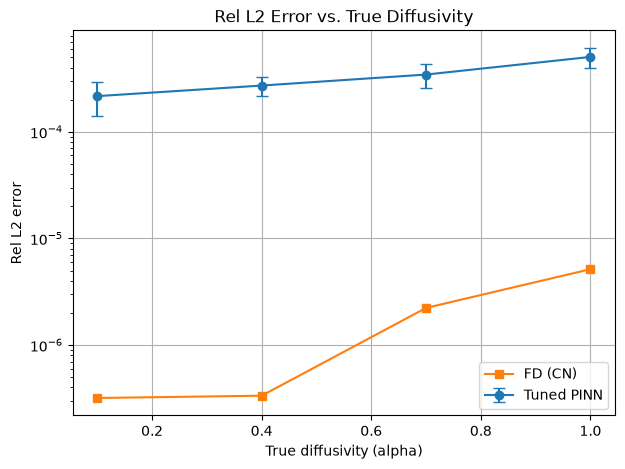

In [15]:
# Sensitivity sweep: vary the forward problem's true diffusivity
# (true_alpha) across a few values, comparing the tuned PINN (the winning
# architecture/hyperparameters from the retrain loop above, frozen -- NOT
# re-tuned per value, for the same reason the inverse sweeps below freeze
# winning_inverse_config: this tests robustness of the already-selected
# config, not a repeat of the expensive HPO search) against FD at each.
# Tests whether the "is PINN-tuning worth it" conclusion holds generally,
# or is specific to the single true_alpha=0.4 value everything else in
# this notebook reports. The true_alpha=0.4 point reuses the already-
# computed final comparison results above instead of retraining a
# duplicate of the identical experiment. Same alpha values used in the
# inverse alpha sweep later, so the two problems' results are directly
# comparable. Seeds 20-24 used here, distinct from forward's baseline/
# retrain-loop seeds (0-4) purely for clarity when tracing through the
# notebook -- forward has no shared-dataset leakage risk the way inverse
# does (no external noisy observations to accidentally reuse), so this
# is a readability choice, not a correctness requirement.
ALPHA_SWEEP_VALUES = [0.1, 0.4, 0.7, 1.0]
winning_forward_config = top_configs[best_config_idx]
alpha_sweep_results = {}
alpha_sweep_start = time.time()

for alpha_val in ALPHA_SWEEP_VALUES:
    u_exact_alpha = torch.sin(torch.pi * x_test_flat) * torch.exp(-alpha_val * (torch.pi**2) * t_test_flat)

    if alpha_val == forward_config["true_alpha"]:
        alpha_sweep_results[alpha_val] = {
            "pinn_rel_l2_mean": pinn_test_rel_l2_mean,
            "pinn_rel_l2_std": pinn_test_rel_l2_std,
            "fd_rel_l2": error_fd,
        }
        print(f"true_alpha={alpha_val}: reused final comparison results (identical config)")
        continue

    sweep_forward_config = {**winning_forward_config, "true_alpha": alpha_val}
    pinn_errors = []
    for seed in range(20, 25):
        set_seed(seed)
        r = train_forward(sweep_forward_config, print_training=False)
        model_device = next(r["model"].parameters()).device
        with torch.no_grad():
            u_pred_alpha = r["model"](x_test_flat.to(model_device), t_test_flat.to(model_device)).cpu()
        pinn_errors.append((torch.norm(u_pred_alpha - u_exact_alpha) / torch.norm(u_exact_alpha)).item())

    _, _, u_fd_alpha, _ = fd_solver(1000, 1000, alpha=alpha_val, compute_error=False)
    X_fd_a, T_fd_a = np.meshgrid(x_fd, t_fd, indexing='ij')
    u_exact_fd_alpha = np.sin(np.pi * X_fd_a) * np.exp(-alpha_val * (np.pi**2) * T_fd_a)
    fd_error_alpha = np.linalg.norm(u_fd_alpha - u_exact_fd_alpha) / np.linalg.norm(u_exact_fd_alpha)

    alpha_sweep_results[alpha_val] = {
        "pinn_rel_l2_mean": float(np.mean(pinn_errors)),
        "pinn_rel_l2_std": float(np.std(pinn_errors)),
        "fd_rel_l2": float(fd_error_alpha),
    }
    print(f"true_alpha={alpha_val}: PINN rel L2 {np.mean(pinn_errors):.4e} ± {np.std(pinn_errors):.4e} | "
          f"FD rel L2 {fd_error_alpha:.4e}")

alpha_sweep_time = time.time() - alpha_sweep_start
print(f"\nForward alpha sensitivity sweep total time: {alpha_sweep_time:.2f}s")

plt.figure(figsize=(7, 5))
xs = sorted(alpha_sweep_results.keys())
pinn_means = [alpha_sweep_results[x]["pinn_rel_l2_mean"] for x in xs]
pinn_stds = [alpha_sweep_results[x]["pinn_rel_l2_std"] for x in xs]
fd_vals = [alpha_sweep_results[x]["fd_rel_l2"] for x in xs]
plt.errorbar(xs, pinn_means, yerr=pinn_stds, marker='o', label='Tuned PINN', capsize=4)
plt.plot(xs, fd_vals, marker='s', label='FD (CN)')
plt.yscale('log')
plt.xlabel('True diffusivity (alpha)')
plt.ylabel('Rel L2 error')
plt.title('Rel L2 Error vs. True Diffusivity')
plt.legend()
plt.grid(True)
plt.show()

**TODO:** (After the final run) Summarize whether the tuning-vs-FD accuracy gap holds across all tested true_alpha values or only near the default.

INVERSE START
**TODO:** Explain the inverse problem's baseline setup and how it mirrors the forward baseline's methodology.

In [16]:
# Baseline (no-tuning) inverse PINN: the exact hyperparameters originally
# used in heat_pinn_basic.ipynb's inverse cell (hardcoded tanh activation,
# all loss terms unweighted), the same way forward_config captures the
# original forward hyperparameters.
baseline_inverse_config = {
    "activation":   "tanh",
    "hidden_size":  20,
    "n_layers":     4,
    "lambda_pde":   1.0,
    "lambda_bc":    1.0,
    "lambda_ic":    1.0,
    "lambda_data":  1.0,
    "N_f":          10000,
    "N_bc":         200,
    "N_ic":         200,
    "N_obs":        10,
    "noise_std":    0.05,
    "alpha_init":   0.1,
    "true_alpha":   0.4,
    "adam_lr":      1e-3,
    "adam_iters":   5000,
    "lbfgs_iters":  500,
}

In [17]:
# Generate the baseline's own observations once, kept fixed across all 5
# seeds below -- same reasoning as the shared x_obs_inv/t_obs_inv/u_obs_inv
# used for Optuna trials further down: comparing seeds should only reflect
# training stochasticity, not a fresh random observation draw each time.
set_seed(0)
x_obs_baseline, t_obs_baseline, u_obs_baseline = generate_noisy_data(baseline_inverse_config)

baseline_inverse_results = []
for seed in range(5):
    set_seed(seed)
    r = train_inverse(baseline_inverse_config, x_obs_baseline, t_obs_baseline, u_obs_baseline, print_training=False)
    baseline_inverse_results.append(r)

baseline_alpha_errors = [r["alpha_error"] for r in baseline_inverse_results]
baseline_inverse_times = [r["train_time"] for r in baseline_inverse_results]

print(f"\nBaseline (no tuning) inverse PINN:")
print(f"  Alpha error: {np.mean(baseline_alpha_errors):.6e} ± {np.std(baseline_alpha_errors):.6e}")
print(f"  Time: {np.mean(baseline_inverse_times):.2f} ± {np.std(baseline_inverse_times):.2f} sec")

[warning] L-BFGS stopped after only 4 closure call(s) (configured for up to 500). Final gradient norm: 2.9828e-04. This may indicate early convergence (fine) or a degenerate step (worth checking).

Total training time: 26.26s
Recovered alpha: 0.453988 | True alpha: 0.4 | Error: 0.053988
[warning] L-BFGS stopped after only 3 closure call(s) (configured for up to 500). Final gradient norm: 4.1544e-04. This may indicate early convergence (fine) or a degenerate step (worth checking).

Total training time: 25.96s
Recovered alpha: 0.452927 | True alpha: 0.4 | Error: 0.052927

Total training time: 29.76s
Recovered alpha: 0.451808 | True alpha: 0.4 | Error: 0.051808
[warning] L-BFGS stopped after only 5 closure call(s) (configured for up to 500). Final gradient norm: 3.0342e-04. This may indicate early convergence (fine) or a degenerate step (worth checking).

Total training time: 26.11s
Recovered alpha: 0.454514 | True alpha: 0.4 | Error: 0.054514

Total training time: 30.08s
Recovered alpha:

In [18]:
# Parameters for generating the inverse problem's synthetic noisy
# observations -- named once here (rather than as a bare literal) since
# forthcoming sensitivity sweeps will vary N_obs and noise_std, and every
# generate_noisy_data(...) call in this section (search stage here, plus
# the confirmation-round and final-evaluation cells below) should draw
# from the same definition of the observation setup rather than each
# retyping its own copy of the same three numbers.
INVERSE_OBS_CONFIG = {
    "N_obs": 50,
    "noise_std": 0.05,
    "true_alpha": 0.4,
}

# Generate the inverse-problem observations once, shared across every Optuna
# trial, so trials are compared on the identical noisy dataset rather than
# each drawing its own random noise realization.
set_seed(0)
x_obs_inv, t_obs_inv, u_obs_inv = generate_noisy_data(INVERSE_OBS_CONFIG)

# Everything about the inverse problem that Optuna does NOT search over --
# defined once here so both objective_inverse (HPO trials) and the
# multi-seed retrain loop later (after be0839c3) build configs from the
# same source instead of two copies that could drift out of sync. N_obs
# and noise_std are deliberately not here: train_inverse never reads them
# (observations are passed in pre-built above), so including them would
# just be dead weight that looks like it configures something it doesn't.
#
# activation, N_f, and the N_bc/N_ic range now match forward's search space
# exactly (previously activation was fixed to "sin" and N_f fixed to 10000,
# with N_bc/N_ic searched over double forward's range) -- decided August 21,
# 2026: the original narrower inverse space was sized for MacBook CPU
# training time, not for any physics-based reason the two problems should
# search differently. Forward's own completed HPO run found tanh
# outperforming sin on a closely related problem, which undercuts the
# "sin is the right basis so fix it" assumption inverse was built on.
# Whether inverse specifically benefits from denser BC/IC point coverage
# (a real, separate hypothesis -- more boundary/IC anchoring could help
# alpha identifiability given only sparse noisy data) is deferred to a
# dedicated follow-up ablation rather than left as an untested asymmetry
# baked into the main comparison.
INVERSE_FIXED_CONFIG = {
    "lambda_pde":  1.0,
    "alpha_init":  0.1,
    "true_alpha":  0.4,
}

def objective_inverse(trial):
    config = {
        **INVERSE_FIXED_CONFIG,
        "hidden_size":  trial.suggest_categorical("hidden_size", [16, 32, 64, 128]),
        "n_layers":     trial.suggest_categorical("n_layers", [3, 4, 5]),
        "activation":   trial.suggest_categorical("activation", ["tanh", "sin"]),
        "lambda_bc":    trial.suggest_float("lambda_bc",  0.001, 1000.0, log=True),
        "lambda_ic":    trial.suggest_float("lambda_ic",  0.001, 1000.0, log=True),
        "lambda_data":  trial.suggest_float("lambda_data",  0.001, 1000.0, log=True),
        "N_f":          trial.suggest_categorical("N_f", [5000, 10000, 20000]),
        "N_bc":         trial.suggest_categorical("N_bc", [100, 200, 400]),
        "N_ic":         trial.suggest_categorical("N_ic", [100, 200, 400]),
        "adam_lr":      trial.suggest_float("adam_lr", 1e-4, 1e-2, log=True),
        "adam_iters":   1500,
        "lbfgs_iters":  500,
    }

    results = train_inverse(config, x_obs_inv, t_obs_inv, u_obs_inv, print_training=False, trial=trial)
    return abs(results["alpha"] - config["true_alpha"])

In [19]:
if os.path.exists("optuna_inverse.db"):
    os.remove("optuna_inverse.db")


**TODO:** Note anything different from the forward search worth calling out (the extra lambda_data term, the search/confirmation/final-evaluation split) before the 300-trial run below.

In [20]:
study = optuna.create_study(
    direction="minimize",
    study_name="inverse_pinn_hpo",
    storage="sqlite:///optuna_inverse.db",
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner(n_startup_trials=15, n_warmup_steps=800, interval_steps=200, n_min_trials=8),
    sampler=optuna.samplers.TPESampler(seed=42)
)

optuna_inverse_search_start = time.time()
study.optimize(
    objective_inverse,
    n_trials=300,
    show_progress_bar=True
)
optuna_inverse_search_time = time.time() - optuna_inverse_search_start

joblib.dump(study, 'inverse_hpo_study.pkl')

print(f"\nTotal Optuna inverse search time: {optuna_inverse_search_time:.2f}s")
print("\nBest trial:")
print(f"  alpha_error: {study.best_trial.value:.4e}")
print(f"  params: {study.best_trial.params}")

# Log-scale y-axis -- objective values span several orders of magnitude
# (early trials near 1, converged trials down near 1e-4), so a linear
# axis crowds nearly every trial against the best-value line and hides
# the actual spread. plot_optimization_history has no built-in log-scale
# option, so the returned plotly figure is updated directly.
opt_history_fig = vis.plot_optimization_history(study)
opt_history_fig.update_yaxes(type="log")
opt_history_fig.show()
vis.plot_param_importances(study).show()

  0%|          | 0/300 [00:00<?, ?it/s]


Total training time: 15.86s
Recovered alpha: nan | True alpha: 0.4 | Error: nan
[W 2026-08-22 18:37:56,178] Trial 0 failed with parameters: {'hidden_size': 32, 'n_layers': 3, 'activation': 'tanh', 'lambda_bc': 17.71884735480682, 'lambda_ic': 0.0013289448722869186, 'lambda_data': 659.871107205407, 'N_f': 5000, 'N_bc': 400, 'N_ic': 400, 'adam_lr': 0.00019010245319870352} because of the following error: The value nan is not acceptable.
[W 2026-08-22 18:37:56,178] Trial 0 failed with value nan.

Total training time: 21.54s
Recovered alpha: 0.390771 | True alpha: 0.4 | Error: 0.009229

Total training time: 20.66s
Recovered alpha: 0.374635 | True alpha: 0.4 | Error: 0.025365

Total training time: 17.92s
Recovered alpha: 0.152310 | True alpha: 0.4 | Error: 0.247690

Total training time: 20.59s
Recovered alpha: nan | True alpha: 0.4 | Error: nan
[W 2026-08-22 18:39:17,237] Trial 4 failed with parameters: {'hidden_size': 16, 'n_layers': 5, 'activation': 'sin', 'lambda_bc': 0.3674904945305324, 

In [21]:
study = optuna.load_study(
    study_name="inverse_pinn_hpo",
    storage="sqlite:///optuna_inverse.db"
)

print(f"\nBest trial:")
print(f"  Alpha error: {study.best_value:.6e}")
print(f"  Config: {study.best_params}")

# See all top configs
print(f"\nTop 5 trials:")
sorted_trials = sorted(study.trials, key=lambda t: t.value if t.value is not None else float('inf'))
for i, trial in enumerate(sorted_trials[:5], 1):
    print(f"{i}. Alpha error: {trial.value:.6e}")
    print(f"   Params: {trial.params}\n")

# Stats
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
print(f"Summary:")
print(f"  Completed: {len(completed)}")
print(f"  Pruned: {len(pruned)}")
print(f"  Pruning saved: {len(pruned)/(len(completed)+len(pruned))*100:.1f}% of trials")



Best trial:
  Alpha error: 1.233220e-05
  Config: {'hidden_size': 64, 'n_layers': 4, 'activation': 'tanh', 'lambda_bc': 33.83155732788466, 'lambda_ic': 0.10504034853050277, 'lambda_data': 10.603582984447831, 'N_f': 20000, 'N_bc': 200, 'N_ic': 400, 'adam_lr': 0.007821712408368715}

Top 5 trials:
1. Alpha error: 1.233220e-05
   Params: {'hidden_size': 64, 'n_layers': 4, 'activation': 'tanh', 'lambda_bc': 33.83155732788466, 'lambda_ic': 0.10504034853050277, 'lambda_data': 10.603582984447831, 'N_f': 20000, 'N_bc': 200, 'N_ic': 400, 'adam_lr': 0.007821712408368715}

2. Alpha error: 1.176238e-04
   Params: {'hidden_size': 64, 'n_layers': 3, 'activation': 'tanh', 'lambda_bc': 0.9738225799294916, 'lambda_ic': 0.038529417527085275, 'lambda_data': 0.9784638373883446, 'N_f': 20000, 'N_bc': 200, 'N_ic': 100, 'adam_lr': 0.007399243797317817}

3. Alpha error: 1.377821e-04
   Params: {'hidden_size': 16, 'n_layers': 4, 'activation': 'tanh', 'lambda_bc': 9.01905332683634, 'lambda_ic': 0.10687502955917

**TODO:** Explain the three-stage search/confirmation/final-evaluation split and why it exists (this is the leakage-prevention design worth walking through carefully), and note what the loss-curve/alpha-convergence plot below it is illustrating.

In [22]:
# Confirmation round: retrain each of Optuna's top 3 configs (by search-
# stage alpha error) across 5 FRESH noisy datasets the search stage never
# saw (seeds 1-5, vs. the search stage's seed 0), and pick the winner by
# mean alpha error across those datasets. Since alpha only exists as a
# byproduct of training on some dataset -- there's no way to "query" a
# trained model against new data the way forward's field can be queried at
# new (x,t) points -- the inverse-problem equivalent of forward's held-out
# test grid is a held-out set of simulated noise realizations. This stage
# only decides WHICH CONFIG WINS; the final accuracy number is reported by
# the final-evaluation cell below on yet another, still-untouched set of
# datasets, so no single dataset both picks a winner and reports its
# accuracy.
top_inverse_configs = [
    {**INVERSE_FIXED_CONFIG, **trial.params, "adam_iters": 3000, "lbfgs_iters": 1500}
    for trial in sorted_trials[:3]
]

all_inverse_config_results = []

for i, config in enumerate(top_inverse_configs, 1):
    config_results = []
    for seed in range(1, 6):
        set_seed(seed)
        x_obs_c, t_obs_c, u_obs_c = generate_noisy_data(INVERSE_OBS_CONFIG)
        r = train_inverse(config, x_obs_c, t_obs_c, u_obs_c, print_training=False)
        config_results.append(r)

    errors = [r["alpha_error"] for r in config_results]
    times = [r["train_time"] for r in config_results]
    print(f"\nInverse config {i}:")
    print(f"  Alpha error: {np.mean(errors):.6e} ± {np.std(errors):.6e}")
    print(f"  Time:        {np.mean(times):.2f} ± {np.std(times):.2f} sec")

    all_inverse_config_results.append(config_results)

# Pick the winning config by its MEAN alpha error across the 5 confirmation
# datasets, not by any single individual run's error.
inverse_config_mean_errors = [np.mean([r["alpha_error"] for r in cr]) for cr in all_inverse_config_results]
best_inverse_config_idx = int(np.argmin(inverse_config_mean_errors))
winning_inverse_config = top_inverse_configs[best_inverse_config_idx]

print(f"\nWinning inverse config (by confirmation-round mean alpha error): Config {best_inverse_config_idx + 1}")


Total training time: 20.31s
Recovered alpha: 0.426898 | True alpha: 0.4 | Error: 0.026898

Total training time: 48.20s
Recovered alpha: 0.409072 | True alpha: 0.4 | Error: 0.009072

Total training time: 33.93s
Recovered alpha: 0.372277 | True alpha: 0.4 | Error: 0.027723

Total training time: 48.02s
Recovered alpha: 0.439425 | True alpha: 0.4 | Error: 0.039425

Total training time: 20.96s
Recovered alpha: 0.397247 | True alpha: 0.4 | Error: 0.002753

Inverse config 1:
  Alpha error: 2.117421e-02 ± 1.337553e-02
  Time:        34.29 ± 12.29 sec

Total training time: 15.99s
Recovered alpha: 0.419855 | True alpha: 0.4 | Error: 0.019855

Total training time: 20.24s
Recovered alpha: 0.407100 | True alpha: 0.4 | Error: 0.007100

Total training time: 17.21s
Recovered alpha: 0.376110 | True alpha: 0.4 | Error: 0.023890

Total training time: 23.10s
Recovered alpha: 0.450528 | True alpha: 0.4 | Error: 0.050528

Total training time: 14.79s
Recovered alpha: 0.393279 | True alpha: 0.4 | Error: 0.00

In [23]:
# Final evaluation: retrain the confirmation round's winner -- frozen, no
# further config selection happens here -- across 5 MORE fresh datasets
# (seeds 6-10), never touched by the search stage or the confirmation
# round. This mean +/- std is what should be quoted as the tuned inverse
# PINN's accuracy, and CN-NLS in the next cell is evaluated on these
# identical datasets for a leakage-free final comparison.
final_inverse_results = []
for seed in range(6, 11):
    set_seed(seed)
    x_obs_f, t_obs_f, u_obs_f = generate_noisy_data(INVERSE_OBS_CONFIG)
    r = train_inverse(winning_inverse_config, x_obs_f, t_obs_f, u_obs_f, print_training=False)
    final_inverse_results.append(r)

tuned_inverse_alpha_error_mean = float(np.mean([r["alpha_error"] for r in final_inverse_results]))
tuned_inverse_alpha_error_std = float(np.std([r["alpha_error"] for r in final_inverse_results]))
tuned_inverse_train_time_mean = float(np.mean([r["train_time"] for r in final_inverse_results]))
tuned_inverse_train_time_std = float(np.std([r["train_time"] for r in final_inverse_results]))

print(f"\nFinal tuned inverse PINN (winning config, evaluated on fresh datasets):")
print(f"  Alpha error:   {tuned_inverse_alpha_error_mean:.6e} ± {tuned_inverse_alpha_error_std:.6e}")
print(f"  Training time: {tuned_inverse_train_time_mean:.2f} ± {tuned_inverse_train_time_std:.2f} sec")

# Use whichever seed's alpha error is closest to the mean as a single
# representative run for the illustrative plot below -- mirrors forward's
# representative-model selection in the top-configs cell.
representative_inverse_idx = int(np.argmin(
    [abs(r["alpha_error"] - tuned_inverse_alpha_error_mean) for r in final_inverse_results]))
inverse_results = final_inverse_results[representative_inverse_idx]


Total training time: 44.01s
Recovered alpha: 0.417423 | True alpha: 0.4 | Error: 0.017423

Total training time: 28.67s
Recovered alpha: 0.409647 | True alpha: 0.4 | Error: 0.009647

Total training time: 36.70s
Recovered alpha: 0.443030 | True alpha: 0.4 | Error: 0.043030

Total training time: 32.07s
Recovered alpha: 0.370784 | True alpha: 0.4 | Error: 0.029216

Total training time: 39.92s
Recovered alpha: 0.381986 | True alpha: 0.4 | Error: 0.018014

Final tuned inverse PINN (winning config, evaluated on fresh datasets):
  Alpha error:   2.346603e-02 ± 1.160174e-02
  Training time: 36.27 ± 5.46 sec


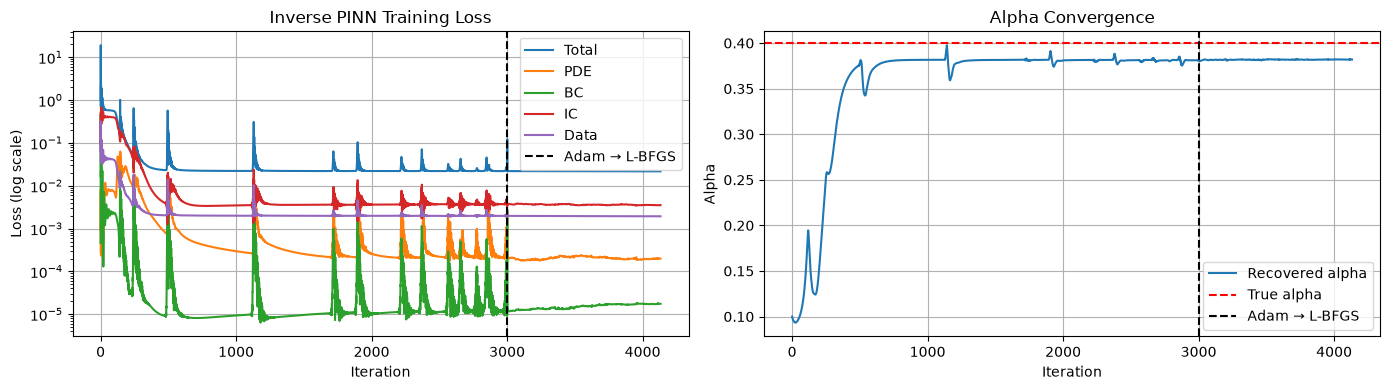

In [24]:
# Illustrative loss-curve / alpha-convergence plot for the winning tuned
# config's representative run (from the retrain loop above) -- mirrors
# forward's representative-run plot, which shows the actual winning model
# rather than a separately hand-set config.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(inverse_results["history_total"], label='Total')
axes[0].semilogy(inverse_results["history_pde"], label='PDE')
axes[0].semilogy(inverse_results["history_bc"], label='BC')
axes[0].semilogy(inverse_results["history_ic"], label='IC')
axes[0].semilogy(inverse_results["history_data"], label='Data')
axes[0].axvline(x=inverse_results["adam_iters"], color='black', linestyle='--', label='Adam → L-BFGS')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss (log scale)')
axes[0].set_title('Inverse PINN Training Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(inverse_results["history_alpha"], label='Recovered alpha')
axes[1].axhline(y=INVERSE_FIXED_CONFIG["true_alpha"], color='r', linestyle='--', label='True alpha')
axes[1].axvline(x=inverse_results["adam_iters"], color='black', linestyle='--', label='Adam → L-BFGS')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Alpha')
axes[1].set_title('Alpha Convergence')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**TODO:** Explain what the CN-NLS comparison and the Baseline/Tuned/CN-NLS table below are comparing, and why CN-NLS has no training-time cost line.

CN-NLS total runtime: 0.36s
CN-NLS total runtime: 0.36s
CN-NLS total runtime: 0.35s
CN-NLS total runtime: 0.36s
CN-NLS total runtime: 0.35s
CN-NLS recovered alpha: 0.412965 | True alpha: 0.4 | Error: 0.012965


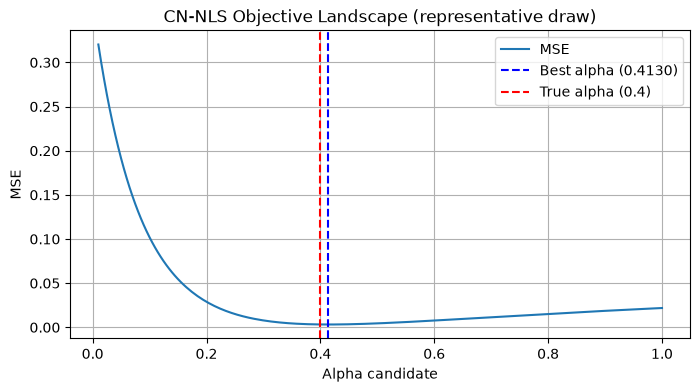


                                Baseline          Tuned         CN-NLS
----------------------------------------------------------------------
Alpha error                          N/A            N/A     1.2965e-02
  mean ± std (5 runs)     5.3343e-02±9.3107e-04 2.3466e-02±1.1602e-02 1.8724e-02±1.2201e-02
Training/opt time (s)                N/A            N/A           0.36
  mean ± std (5 runs)         27.64±1.87     36.27±5.46      0.36±0.00
Optuna search time (s)               N/A        3575.42            N/A


In [25]:
true_alpha = INVERSE_FIXED_CONFIG["true_alpha"]

# Run CN-NLS against the SAME 5 final-evaluation datasets as the tuned PINN
# above (each stored on its own result dict by train_inverse), so PINN and
# CN-NLS are compared on identical observations and CN-NLS gets the same
# across-datasets robustness treatment instead of being judged on a single
# noise realization.
cn_nls_results = []
for r in final_inverse_results:
    best_alpha, mse_history, alpha_candidates, cn_nls_time = cn_nls_baseline(
        {"n_alpha_candidates": 200}, r["x_obs"], r["t_obs"], r["u_obs"])
    cn_nls_results.append({
        "best_alpha": best_alpha,
        "mse_history": mse_history,
        "alpha_candidates": alpha_candidates,
        "cn_nls_time": cn_nls_time,
        "alpha_error": abs(best_alpha - true_alpha),
    })

cn_nls_alpha_errors = [c["alpha_error"] for c in cn_nls_results]
cn_nls_times = [c["cn_nls_time"] for c in cn_nls_results]
cn_nls_alpha_error_mean = float(np.mean(cn_nls_alpha_errors))
cn_nls_alpha_error_std = float(np.std(cn_nls_alpha_errors))
cn_nls_time_mean = float(np.mean(cn_nls_times))
cn_nls_time_std = float(np.std(cn_nls_times))

# Use whichever draw's alpha error is closest to the mean as a single
# representative run for the landscape plot below -- illustrative only.
representative_cn_idx = int(np.argmin([abs(c["alpha_error"] - cn_nls_alpha_error_mean) for c in cn_nls_results]))
best_alpha = cn_nls_results[representative_cn_idx]["best_alpha"]
mse_history = cn_nls_results[representative_cn_idx]["mse_history"]
alpha_candidates = cn_nls_results[representative_cn_idx]["alpha_candidates"]
cn_nls_time = cn_nls_results[representative_cn_idx]["cn_nls_time"]
cn_nls_alpha_error = cn_nls_results[representative_cn_idx]["alpha_error"]

print(f"CN-NLS recovered alpha: {best_alpha:.6f} | True alpha: {true_alpha} | Error: {cn_nls_alpha_error:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(alpha_candidates, mse_history, label='MSE')
plt.axvline(x=best_alpha, color='b', linestyle='--', label=f'Best alpha ({best_alpha:.4f})')
plt.axvline(x=true_alpha, color='r', linestyle='--', label=f'True alpha ({true_alpha})')
plt.xlabel('Alpha candidate')
plt.ylabel('MSE')
plt.title('CN-NLS Objective Landscape (representative draw)')
plt.legend()
plt.grid(True)
plt.show()

# Baseline / Tuned / CN-NLS comparison table, mirroring forward's final
# summary table -- alpha error and cost, side by side. Row label says
# "runs" rather than "seeds": Baseline's 5 runs share one dataset (only
# training seed varies), but Tuned's 5 runs each use a different dataset,
# and CN-NLS has no training randomness at all -- its variation is entirely
# from the different datasets. "Seeds" would only be accurate for Baseline.
print(f"\n{'':25} {'Baseline':>14} {'Tuned':>14} {'CN-NLS':>14}")
print(f"{'-'*70}")
print(f"{'Alpha error':25} {'N/A':>14} {'N/A':>14} {cn_nls_alpha_error:>14.4e}")
print(f"{'  mean ± std (5 runs)':25} {f'{np.mean(baseline_alpha_errors):.4e}±{np.std(baseline_alpha_errors):.4e}':>14} {f'{tuned_inverse_alpha_error_mean:.4e}±{tuned_inverse_alpha_error_std:.4e}':>14} {f'{cn_nls_alpha_error_mean:.4e}±{cn_nls_alpha_error_std:.4e}':>14}")
print(f"{'Training/opt time (s)':25} {'N/A':>14} {'N/A':>14} {cn_nls_time:>14.2f}")
print(f"{'  mean ± std (5 runs)':25} {f'{np.mean(baseline_inverse_times):.2f}±{np.std(baseline_inverse_times):.2f}':>14} {f'{tuned_inverse_train_time_mean:.2f}±{tuned_inverse_train_time_std:.2f}':>14} {f'{cn_nls_time_mean:.2f}±{cn_nls_time_std:.2f}':>14}")
print(f"{'Optuna search time (s)':25} {'N/A':>14} {optuna_inverse_search_time:>14.2f} {'N/A':>14}")

**TODO:** (After the final run) Summarize how the tuned PINN compares to CN-NLS on accuracy and cost, and state your position on the paper's framing for this result.

In [ ]:
# CPU-only control-timing run: same winning frozen inverse config as the
# GPU numbers reported above, explicit device="cpu", reusing the exact same
# 5 final-evaluation observation datasets (seeds 6-10) already generated for
# the GPU run -- so this is a hardware-context data point, not a repeat of
# the leakage-checked accuracy claim on different data.
cpu_inverse_results = []
for seed, r_gpu in zip(range(6, 11), final_inverse_results):
    set_seed(seed)
    r = train_inverse(winning_inverse_config, r_gpu["x_obs"], r_gpu["t_obs"], r_gpu["u_obs"],
                       print_training=False, device=torch.device("cpu"))
    cpu_inverse_results.append(r)

cpu_inverse_train_time_mean = float(np.mean([r["train_time"] for r in cpu_inverse_results]))
cpu_inverse_train_time_std = float(np.std([r["train_time"] for r in cpu_inverse_results]))

print(f"\nCPU control (winning inverse config, device='cpu', 5 runs):")
print(f"  Training time: {cpu_inverse_train_time_mean:.2f} ± {cpu_inverse_train_time_std:.2f} sec  (GPU: {tuned_inverse_train_time_mean:.2f} ± {tuned_inverse_train_time_std:.2f} sec)")

**TODO:** Explain why these three sweeps (noise, observation count, true_alpha) exist and what each one tests about the tuned config's robustness.


Total training time: 23.60s
Recovered alpha: 0.403358 | True alpha: 0.4 | Error: 0.003358
CN-NLS total runtime: 0.36s

Total training time: 21.01s
Recovered alpha: 0.392466 | True alpha: 0.4 | Error: 0.007534
CN-NLS total runtime: 0.36s

Total training time: 22.13s
Recovered alpha: 0.399222 | True alpha: 0.4 | Error: 0.000778
CN-NLS total runtime: 0.36s

Total training time: 20.40s
Recovered alpha: 0.401214 | True alpha: 0.4 | Error: 0.001214
CN-NLS total runtime: 0.36s

Total training time: 21.42s
Recovered alpha: 0.403074 | True alpha: 0.4 | Error: 0.003074
CN-NLS total runtime: 0.35s
noise_std=0.01: PINN alpha error 3.1914e-03 ± 2.3931e-03 | CN-NLS alpha error 3.3769e-03 ± 1.8404e-03
noise_std=0.05: reused final-evaluation results (identical config)

Total training time: 30.74s
Recovered alpha: 0.434864 | True alpha: 0.4 | Error: 0.034864
CN-NLS total runtime: 0.36s

Total training time: 48.46s
Recovered alpha: 0.332313 | True alpha: 0.4 | Error: 0.067687
CN-NLS total runtime: 0.35

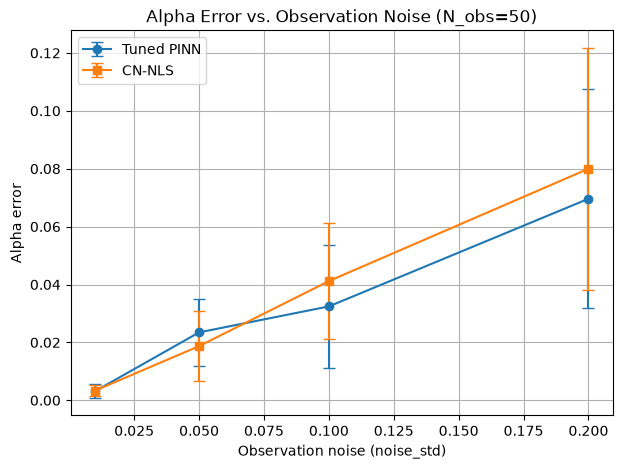

In [26]:
# Sensitivity sweep 1: vary observation noise (noise_std) at fixed
# N_obs=50, comparing the tuned PINN (winning_inverse_config, frozen from
# the confirmation round above -- NOT re-tuned per point, since the point
# is testing how robust the already-selected config is to noise, not
# re-running the expensive HPO search 4 more times) against CN-NLS at each
# noise level. The noise_std=0.05 point reuses the already-computed final
# results above instead of retraining a duplicate of the identical
# experiment. Seeds 11-15 used here -- search=0, confirmation=1-5,
# final-eval=6-10, this sweep=11-15, the N_obs sweep below=16-20 -- so no
# dataset is reused across any two stages, including between the sweeps.
NOISE_SWEEP_VALUES = [0.01, 0.05, 0.1, 0.2]
noise_sweep_results = {}
noise_sweep_start = time.time()

for noise_std in NOISE_SWEEP_VALUES:
    if noise_std == INVERSE_OBS_CONFIG["noise_std"]:
        noise_sweep_results[noise_std] = {
            "pinn_alpha_error_mean": tuned_inverse_alpha_error_mean,
            "pinn_alpha_error_std": tuned_inverse_alpha_error_std,
            "cn_nls_alpha_error_mean": cn_nls_alpha_error_mean,
            "cn_nls_alpha_error_std": cn_nls_alpha_error_std,
        }
        print(f"noise_std={noise_std}: reused final-evaluation results (identical config)")
        continue

    sweep_obs_config = {**INVERSE_OBS_CONFIG, "noise_std": noise_std}
    pinn_errors, cn_errors = [], []
    for seed in range(11, 16):
        set_seed(seed)
        x_obs_s, t_obs_s, u_obs_s = generate_noisy_data(sweep_obs_config)
        r = train_inverse(winning_inverse_config, x_obs_s, t_obs_s, u_obs_s, print_training=False)
        pinn_errors.append(r["alpha_error"])

        best_alpha_s, _, _, _ = cn_nls_baseline({"n_alpha_candidates": 200}, r["x_obs"], r["t_obs"], r["u_obs"])
        cn_errors.append(abs(best_alpha_s - true_alpha))

    noise_sweep_results[noise_std] = {
        "pinn_alpha_error_mean": float(np.mean(pinn_errors)),
        "pinn_alpha_error_std": float(np.std(pinn_errors)),
        "cn_nls_alpha_error_mean": float(np.mean(cn_errors)),
        "cn_nls_alpha_error_std": float(np.std(cn_errors)),
    }
    print(f"noise_std={noise_std}: PINN alpha error {np.mean(pinn_errors):.4e} ± {np.std(pinn_errors):.4e} | "
          f"CN-NLS alpha error {np.mean(cn_errors):.4e} ± {np.std(cn_errors):.4e}")

noise_sweep_time = time.time() - noise_sweep_start
print(f"\nNoise sensitivity sweep total time: {noise_sweep_time:.2f}s")

plt.figure(figsize=(7, 5))
xs = sorted(noise_sweep_results.keys())
pinn_means = [noise_sweep_results[x]["pinn_alpha_error_mean"] for x in xs]
pinn_stds = [noise_sweep_results[x]["pinn_alpha_error_std"] for x in xs]
cn_means = [noise_sweep_results[x]["cn_nls_alpha_error_mean"] for x in xs]
cn_stds = [noise_sweep_results[x]["cn_nls_alpha_error_std"] for x in xs]
plt.errorbar(xs, pinn_means, yerr=pinn_stds, marker='o', label='Tuned PINN', capsize=4)
plt.errorbar(xs, cn_means, yerr=cn_stds, marker='s', label='CN-NLS', capsize=4)
plt.xlabel('Observation noise (noise_std)')
plt.ylabel('Alpha error')
plt.title(f'Alpha Error vs. Observation Noise (N_obs={INVERSE_OBS_CONFIG["N_obs"]})')
plt.legend()
plt.grid(True)
plt.show()

**TODO:** (After the final run) Summarize how accuracy degrades, or doesn't, as observation noise increases, for the PINN versus CN-NLS.


Total training time: 48.33s
Recovered alpha: 0.380275 | True alpha: 0.4 | Error: 0.019725
CN-NLS total runtime: 0.35s

Total training time: 48.04s
Recovered alpha: 0.490253 | True alpha: 0.4 | Error: 0.090253
CN-NLS total runtime: 0.37s

Total training time: 47.80s
Recovered alpha: 0.471977 | True alpha: 0.4 | Error: 0.071977
CN-NLS total runtime: 0.36s

Total training time: 47.94s
Recovered alpha: 0.435855 | True alpha: 0.4 | Error: 0.035855
CN-NLS total runtime: 0.36s

Total training time: 32.05s
Recovered alpha: 0.414355 | True alpha: 0.4 | Error: 0.014355
CN-NLS total runtime: 0.36s
N_obs=10: PINN alpha error 4.6433e-02 ± 2.9755e-02 | CN-NLS alpha error 3.5849e-02 ± 1.8508e-02

Total training time: 48.11s
Recovered alpha: 0.398109 | True alpha: 0.4 | Error: 0.001891
CN-NLS total runtime: 0.36s

Total training time: 37.40s
Recovered alpha: 0.398310 | True alpha: 0.4 | Error: 0.001690
CN-NLS total runtime: 0.36s

Total training time: 25.02s
Recovered alpha: 0.382202 | True alpha: 0.

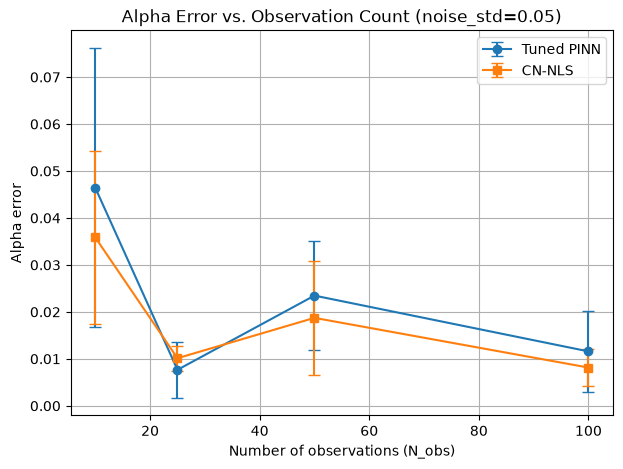

In [27]:
# Sensitivity sweep 2: vary observation count (N_obs) at fixed
# noise_std=0.05, same methodology as the noise sweep above -- frozen
# winning_inverse_config, N_obs=50 point reuses the already-computed final
# results, seeds 16-20 (distinct from every other stage including the
# noise sweep's 11-15).
NOBS_SWEEP_VALUES = [10, 25, 50, 100]
nobs_sweep_results = {}
nobs_sweep_start = time.time()

for n_obs in NOBS_SWEEP_VALUES:
    if n_obs == INVERSE_OBS_CONFIG["N_obs"]:
        nobs_sweep_results[n_obs] = {
            "pinn_alpha_error_mean": tuned_inverse_alpha_error_mean,
            "pinn_alpha_error_std": tuned_inverse_alpha_error_std,
            "cn_nls_alpha_error_mean": cn_nls_alpha_error_mean,
            "cn_nls_alpha_error_std": cn_nls_alpha_error_std,
        }
        print(f"N_obs={n_obs}: reused final-evaluation results (identical config)")
        continue

    sweep_obs_config = {**INVERSE_OBS_CONFIG, "N_obs": n_obs}
    pinn_errors, cn_errors = [], []
    for seed in range(16, 21):
        set_seed(seed)
        x_obs_s, t_obs_s, u_obs_s = generate_noisy_data(sweep_obs_config)
        r = train_inverse(winning_inverse_config, x_obs_s, t_obs_s, u_obs_s, print_training=False)
        pinn_errors.append(r["alpha_error"])

        best_alpha_s, _, _, _ = cn_nls_baseline({"n_alpha_candidates": 200}, r["x_obs"], r["t_obs"], r["u_obs"])
        cn_errors.append(abs(best_alpha_s - true_alpha))

    nobs_sweep_results[n_obs] = {
        "pinn_alpha_error_mean": float(np.mean(pinn_errors)),
        "pinn_alpha_error_std": float(np.std(pinn_errors)),
        "cn_nls_alpha_error_mean": float(np.mean(cn_errors)),
        "cn_nls_alpha_error_std": float(np.std(cn_errors)),
    }
    print(f"N_obs={n_obs}: PINN alpha error {np.mean(pinn_errors):.4e} ± {np.std(pinn_errors):.4e} | "
          f"CN-NLS alpha error {np.mean(cn_errors):.4e} ± {np.std(cn_errors):.4e}")

nobs_sweep_time = time.time() - nobs_sweep_start
print(f"\nN_obs sensitivity sweep total time: {nobs_sweep_time:.2f}s")

plt.figure(figsize=(7, 5))
xs = sorted(nobs_sweep_results.keys())
pinn_means = [nobs_sweep_results[x]["pinn_alpha_error_mean"] for x in xs]
pinn_stds = [nobs_sweep_results[x]["pinn_alpha_error_std"] for x in xs]
cn_means = [nobs_sweep_results[x]["cn_nls_alpha_error_mean"] for x in xs]
cn_stds = [nobs_sweep_results[x]["cn_nls_alpha_error_std"] for x in xs]
plt.errorbar(xs, pinn_means, yerr=pinn_stds, marker='o', label='Tuned PINN', capsize=4)
plt.errorbar(xs, cn_means, yerr=cn_stds, marker='s', label='CN-NLS', capsize=4)
plt.xlabel('Number of observations (N_obs)')
plt.ylabel('Alpha error')
plt.title(f'Alpha Error vs. Observation Count (noise_std={INVERSE_OBS_CONFIG["noise_std"]})')
plt.legend()
plt.grid(True)
plt.show()

**TODO:** (After the final run) Summarize how accuracy changes with fewer or more observations, for the PINN versus CN-NLS.


Total training time: 34.77s
Recovered alpha: 0.102698 | True alpha: 0.1 | Error: 0.002698
CN-NLS total runtime: 0.36s

Total training time: 48.05s
Recovered alpha: 0.103575 | True alpha: 0.1 | Error: 0.003575
CN-NLS total runtime: 0.36s

Total training time: 48.05s
Recovered alpha: 0.100868 | True alpha: 0.1 | Error: 0.000868
CN-NLS total runtime: 0.37s

Total training time: 31.66s
Recovered alpha: 0.109035 | True alpha: 0.1 | Error: 0.009035
CN-NLS total runtime: 0.36s

Total training time: 47.86s
Recovered alpha: 0.098386 | True alpha: 0.1 | Error: 0.001614
CN-NLS total runtime: 0.36s
true_alpha=0.1: PINN alpha error 3.5579e-03 ± 2.8897e-03 | CN-NLS alpha error 2.8945e-03 ± 1.9941e-03
true_alpha=0.4: reused final-evaluation results (identical config)

Total training time: 48.32s
Recovered alpha: 0.748917 | True alpha: 0.7 | Error: 0.048917
CN-NLS total runtime: 0.36s

Total training time: 43.79s
Recovered alpha: 0.699299 | True alpha: 0.7 | Error: 0.000701
CN-NLS total runtime: 0.35

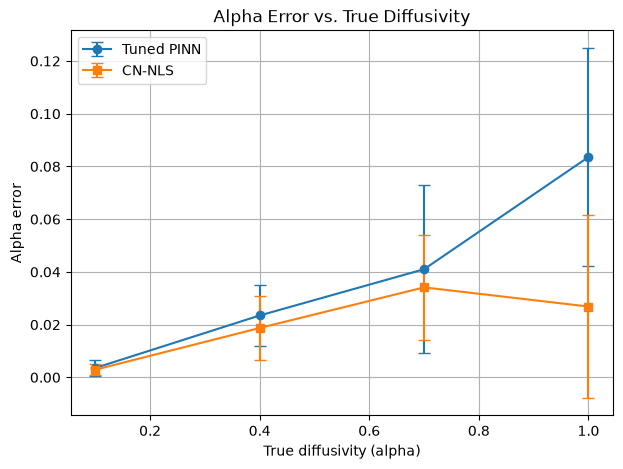

In [28]:
# Sensitivity sweep 3: vary the inverse problem's true diffusivity
# (true_alpha) across the same values used in forward's alpha sweep above,
# so the two problems' generalization-beyond-alpha=0.4 results are directly
# comparable. Freezes winning_inverse_config -- only true_alpha changes per
# point, alpha_init stays fixed at its already-tuned starting value (0.1)
# rather than scaling with the swept alpha. This is deliberate, not an
# oversight: a real deployment of this same tuned recipe on a genuinely
# different diffusivity would not know to adjust alpha_init either, so
# keeping it fixed is the realistic test of how the recipe generalizes,
# not an unfair handicap. All sweep values must stay within CN-NLS's fixed
# [0.01, 1.0] search range (cn_nls_baseline's own alpha_candidates grid,
# unchanged per point) for CN-NLS to have any chance of finding them.
# The true_alpha=0.4 point reuses the already-computed final-evaluation/
# CN-NLS results. Seeds 21-25 used here, distinct from every other stage.
ALPHA_SWEEP_VALUES_INV = [0.1, 0.4, 0.7, 1.0]
inverse_alpha_sweep_results = {}
inverse_alpha_sweep_start = time.time()

for alpha_val in ALPHA_SWEEP_VALUES_INV:
    if alpha_val == INVERSE_OBS_CONFIG["true_alpha"]:
        inverse_alpha_sweep_results[alpha_val] = {
            "pinn_alpha_error_mean": tuned_inverse_alpha_error_mean,
            "pinn_alpha_error_std": tuned_inverse_alpha_error_std,
            "cn_nls_alpha_error_mean": cn_nls_alpha_error_mean,
            "cn_nls_alpha_error_std": cn_nls_alpha_error_std,
        }
        print(f"true_alpha={alpha_val}: reused final-evaluation results (identical config)")
        continue

    sweep_obs_config_a = {**INVERSE_OBS_CONFIG, "true_alpha": alpha_val}
    sweep_inverse_config_a = {**winning_inverse_config, "true_alpha": alpha_val}
    pinn_errors, cn_errors = [], []
    for seed in range(21, 26):
        set_seed(seed)
        x_obs_a, t_obs_a, u_obs_a = generate_noisy_data(sweep_obs_config_a)
        r = train_inverse(sweep_inverse_config_a, x_obs_a, t_obs_a, u_obs_a, print_training=False)
        pinn_errors.append(r["alpha_error"])

        best_alpha_a, _, _, _ = cn_nls_baseline({"n_alpha_candidates": 200}, r["x_obs"], r["t_obs"], r["u_obs"])
        cn_errors.append(abs(best_alpha_a - alpha_val))

    inverse_alpha_sweep_results[alpha_val] = {
        "pinn_alpha_error_mean": float(np.mean(pinn_errors)),
        "pinn_alpha_error_std": float(np.std(pinn_errors)),
        "cn_nls_alpha_error_mean": float(np.mean(cn_errors)),
        "cn_nls_alpha_error_std": float(np.std(cn_errors)),
    }
    print(f"true_alpha={alpha_val}: PINN alpha error {np.mean(pinn_errors):.4e} ± {np.std(pinn_errors):.4e} | "
          f"CN-NLS alpha error {np.mean(cn_errors):.4e} ± {np.std(cn_errors):.4e}")

inverse_alpha_sweep_time = time.time() - inverse_alpha_sweep_start
print(f"\nInverse alpha sensitivity sweep total time: {inverse_alpha_sweep_time:.2f}s")

plt.figure(figsize=(7, 5))
xs = sorted(inverse_alpha_sweep_results.keys())
pinn_means = [inverse_alpha_sweep_results[x]["pinn_alpha_error_mean"] for x in xs]
pinn_stds = [inverse_alpha_sweep_results[x]["pinn_alpha_error_std"] for x in xs]
cn_means = [inverse_alpha_sweep_results[x]["cn_nls_alpha_error_mean"] for x in xs]
cn_stds = [inverse_alpha_sweep_results[x]["cn_nls_alpha_error_std"] for x in xs]
plt.errorbar(xs, pinn_means, yerr=pinn_stds, marker='o', label='Tuned PINN', capsize=4)
plt.errorbar(xs, cn_means, yerr=cn_stds, marker='s', label='CN-NLS', capsize=4)
plt.xlabel('True diffusivity (alpha)')
plt.ylabel('Alpha error')
plt.title('Alpha Error vs. True Diffusivity')
plt.legend()
plt.grid(True)
plt.show()

**TODO:** (After the final run) Summarize whether CN-NLS's advantage over the tuned PINN holds across all tested true_alpha values.